# Phase 2.5 - Data Preprocessing

## Objective

This notebook prepares the feature-engineered dataset for model training.

Tasks include:

- Load engineered dataset
- Verify dataset integrity
- Train-Validation-Test Split
- Feature & Target Separation
- Feature Scaling
- Save processed datasets

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [2]:
DATA_PATH = Path("data/processed/pjm_feature_engineered.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Datetime"],
    index_col="Datetime"
)

print(df.head())

print("\nDataset Shape:",df.shape)

                     PJME_MW  Year  Quarter  Month  Week  Day  DayOfWeek  \
Datetime                                                                   
2002-01-08 01:00:00  29445.0  2002        1      1     2    8          1   
2002-01-08 02:00:00  28670.0  2002        1      1     2    8          1   
2002-01-08 03:00:00  28375.0  2002        1      1     2    8          1   
2002-01-08 04:00:00  28542.0  2002        1      1     2    8          1   
2002-01-08 05:00:00  29261.0  2002        1      1     2    8          1   

                     DayOfYear  Hour  IsWeekend  Hour_sin  Hour_cos   Day_sin  \
Datetime                                                                        
2002-01-08 01:00:00          8     1          0  0.258819  0.965926  0.781831   
2002-01-08 02:00:00          8     2          0  0.500000  0.866025  0.781831   
2002-01-08 03:00:00          8     3          0  0.707107  0.707107  0.781831   
2002-01-08 04:00:00          8     4          0  0.866025  0.5

In [3]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145223 entries, 2002-01-08 01:00:00 to 2018-08-02 23:00:00
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PJME_MW          145223 non-null  float64
 1   Year             145223 non-null  int64  
 2   Quarter          145223 non-null  int64  
 3   Month            145223 non-null  int64  
 4   Week             145223 non-null  int64  
 5   Day              145223 non-null  int64  
 6   DayOfWeek        145223 non-null  int64  
 7   DayOfYear        145223 non-null  int64  
 8   Hour             145223 non-null  int64  
 9   IsWeekend        145223 non-null  int64  
 10  Hour_sin         145223 non-null  float64
 11  Hour_cos         145223 non-null  float64
 12  Day_sin          145223 non-null  float64
 13  Day_cos          145223 non-null  float64
 14  Month_sin        145223 non-null  float64
 15  Month_cos        145223 non-nul

In [4]:
print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum().sum())

MISSING VALUES
0


In [5]:
X = df.drop(columns=["Target"])

y = df["Target"]

print("Features Shape :",X.shape)
print("Target Shape :",y.shape)

Features Shape : (145223, 32)
Target Shape : (145223,)


In [6]:
train_size = int(len(df)*0.7)

valid_size = int(len(df)*0.15)

X_train = X.iloc[:train_size]

X_valid = X.iloc[train_size:train_size+valid_size]

X_test = X.iloc[train_size+valid_size:]

y_train = y.iloc[:train_size]

y_valid = y.iloc[train_size:train_size+valid_size]

y_test = y.iloc[train_size+valid_size:]

In [7]:
print("="*60)
print("TRAIN VALID TEST SHAPES")
print("="*60)

print("Train :",X_train.shape)

print("Validation :",X_valid.shape)

print("Test :",X_test.shape)

TRAIN VALID TEST SHAPES
Train : (101656, 32)
Validation : (21783, 32)
Test : (21784, 32)


In [9]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid),
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [10]:
X_train_scaled.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
PJME_MW,101656.0,-3.131376e-17,1.000005,-2.748617,-0.699388,-0.092353,0.536794,4.552725
Year,101656.0,1.274023e-14,1.000005,-1.588413,-0.992087,-0.097598,0.796892,1.691381
Quarter,101656.0,-1.028881e-16,1.000005,-1.325437,-1.325437,-0.425656,0.474125,1.373907
Month,101656.0,-2.684036e-17,1.000005,-1.579131,-0.995451,-0.119930,0.755590,1.631111
Week,101656.0,1.319651e-16,1.000005,-1.678862,-0.876524,-0.007324,0.861876,1.797938


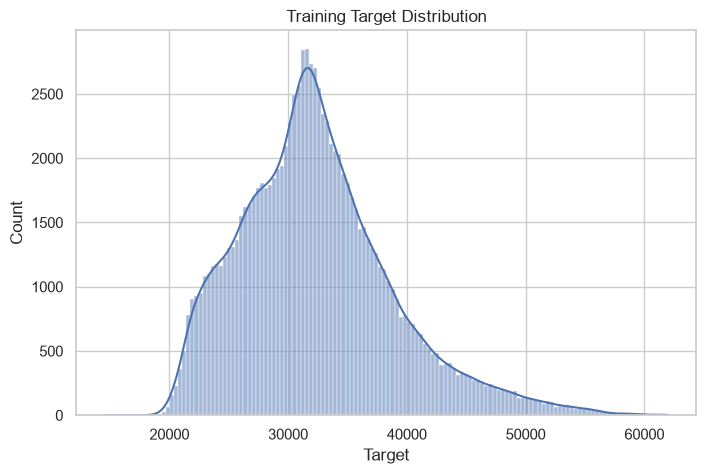

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(y_train,kde=True)

plt.title("Training Target Distribution")

plt.show()

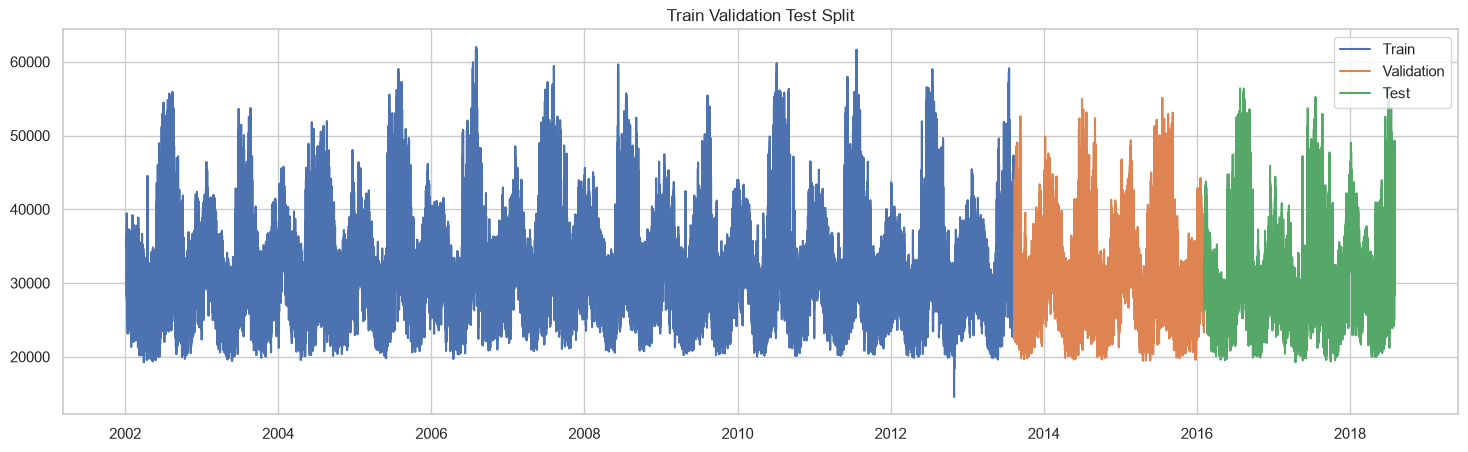

In [12]:
plt.figure(figsize=(18,5))

plt.plot(y_train,label="Train")

plt.plot(y_valid,label="Validation")

plt.plot(y_test,label="Test")

plt.legend()

plt.title("Train Validation Test Split")

plt.show()

In [13]:
output = Path("data/final")

output.mkdir(parents=True,exist_ok=True)

X_train_scaled.to_csv(output/"X_train.csv")
X_valid_scaled.to_csv(output/"X_valid.csv")
X_test_scaled.to_csv(output/"X_test.csv")

y_train.to_csv(output/"y_train.csv")
y_valid.to_csv(output/"y_valid.csv")
y_test.to_csv(output/"y_test.csv")

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [14]:
import joblib

model_path = Path("models")

model_path.mkdir(parents=True,exist_ok=True)

joblib.dump(
    scaler,
    model_path/"scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [15]:
summary = pd.DataFrame({

    "Dataset":[
        "X_train",
        "X_valid",
        "X_test",
        "y_train",
        "y_valid",
        "y_test"
    ],

    "Rows":[
        len(X_train),
        len(X_valid),
        len(X_test),
        len(y_train),
        len(y_valid),
        len(y_test)
    ]

})

summary

,Dataset,Rows
0,X_train,101656
1,X_valid,21783
2,X_test,21784
3,y_train,101656
4,y_valid,21783
5,y_test,21784
